# Models Comparison

Runs all three trained models, Baseline and Enhanced DeepLabV3+, and YOLO26, on one shared pool
of 2,000 images that none of them have seen in training, validation, calibration, or their own
test set. A stricter, independent check on top of each model's own result, using a simple metric:
percent of images predicted right, correct if the overlap with ground truth is at least 50
percent.

Also plots training curves for all three models from their real per epoch logs.

## 1. Setup

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

CUDA available: True
GPU: Tesla T4


In [7]:
!pip install -q awscli segmentation-models-pytorch ultralytics
!aws s3 cp s3://intelinair-data-releases/agriculture-vision/cvpr_challenge_2021/supervised/Agriculture-Vision-2021.tar.gz "/content/Agriculture-Vision-2021.tar.gz" --no-sign-request
!tar -xzf "/content/Agriculture-Vision-2021.tar.gz" -C /content
import os
print("dataset exists:", os.path.exists("/content/Agriculture-Vision-2021"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://intelinair-data-releases/agriculture-vision/cvpr_challenge_2021/supervised/Agriculture-Vision-2021.tar.gz to ./Agriculture-Vision-2021.tar.gz
dataset exists: True


In [26]:
import os, random
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from ultralytics import YOLO
from ultralytics.nn.tasks import SemanticSegmentationModel

ROOT = "/content/Agriculture-Vision-2021"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 2. Config

In [9]:
CONFIG = {
    "seed": 42,
    "positive_coverage_threshold": 0.20,

    # Historical CONFIG sizes for each prior run, needed to reconstruct exactly which images
    # each one already used, so this comparison pool can genuinely exclude all of them.
    "baseline_train_pos": 400, "baseline_train_neg": 400,
    "baseline_val_pos": 100, "baseline_val_neg": 100,
    "baseline_test_pos": 100, "baseline_test_neg": 100,

    # Enhanced DeepLabV3+ and YOLO26 used the IDENTICAL split (same seed, same sizes, same code),
    # so one reconstruction covers both.
    "enhanced_train_pos": 1500, "enhanced_train_neg": 1500,
    "enhanced_val_pos": 200, "enhanced_val_neg": 200,
    "enhanced_test_pos": 100, "enhanced_test_neg": 100,

    # This comparison's own unseen pool
    "unseen_pos": 1000, "unseen_neg": 1000,

    # Correctness rule: an image counts as "predicted right" if the model hits >=50% overlap.
    "iou_correct_threshold": 0.5,
    "fp_correct_threshold": 0.5,  # clean image correct if false-positive rate <= this

    # Model checkpoints
    "baseline_ckpt": "/content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Baseline/best_deeplabv3plus.pth",
    "baseline_thresh": 0.80,
    "enhanced_ckpt": "/content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/best_deeplabv3plus.pth",
    "enhanced_thresh": 0.45,
    "yolo_ckpt": "/content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/yolo26s_sem_drydown/weights/best.pt",
    "yolo_results_csv": "/content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/yolo26s_sem_drydown/results.csv",
    "baseline_log_csv": "/content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Baseline/training_log.csv",
    "enhanced_log_csv": "/content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced/training_log.csv",
    "yolo_imgsz": 512,

    "out_dir": "/content/drive/MyDrive/Rizoma/Models Comparison",
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
os.makedirs(CONFIG["out_dir"], exist_ok=True)
print("Config loaded")

Config loaded


## 3. Reconstruct Every Prior Split

Rebuilds the same field split logic each notebook used, so the unseen pool can genuinely exclude
every image any of them touched. The field partition is the same across runs regardless of sample
size, but the specific images picked differ, so both the Baseline's and the Enhanced's actual used
files are reconstructed and combined.

In [10]:
def coverage_map(split):
    folder = f"{ROOT}/{split}/labels/drydown"
    result = {}
    for f in os.listdir(folder):
        m = np.array(Image.open(os.path.join(folder, f)))
        result[f] = (m > 0).mean()
    return result

train_cov = coverage_map("train")
val_cov = coverage_map("val")

def build_field_partition(cov_dict, threshold):
    field_pos_counts = {}
    for f, c in cov_dict.items():
        if c >= threshold:
            field = f.split("_")[0]
            field_pos_counts[field] = field_pos_counts.get(field, 0) + 1

    fields = sorted(set(f.split("_")[0] for f in cov_dict))
    fields_with_pos = sorted(
        [f for f in fields if f in field_pos_counts],
        key=lambda f: field_pos_counts[f],
        reverse=True,
    )
    fields_without_pos = [f for f in fields if f not in field_pos_counts]
    random.shuffle(fields_without_pos)

    val_fields_set, test_fields_set = set(), set()
    val_pos_total, test_pos_total = 0, 0
    for f in fields_with_pos:
        if val_pos_total <= test_pos_total:
            val_fields_set.add(f)
            val_pos_total += field_pos_counts[f]
        else:
            test_fields_set.add(f)
            test_pos_total += field_pos_counts[f]
    for i, f in enumerate(fields_without_pos):
        (val_fields_set if i % 2 == 0 else test_fields_set).add(f)
    return val_fields_set, test_fields_set

def pick(cov_dict, n_pos, n_neg, allowed_fields=None):
    threshold = CONFIG["positive_coverage_threshold"]
    pos = [f for f, c in cov_dict.items() if c >= threshold and (allowed_fields is None or f.split("_")[0] in allowed_fields)]
    neg = [f for f, c in cov_dict.items() if c == 0 and (allowed_fields is None or f.split("_")[0] in allowed_fields)]
    return random.sample(pos, n_pos), random.sample(neg, n_neg)

# Reset RNG to seed before EACH reconstruction, since each historical notebook run started fresh
# from CONFIG["seed"] too -- reproducing that exactly is what makes this deterministic.
random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
val_fields_set, test_fields_set = build_field_partition(val_cov, CONFIG["positive_coverage_threshold"])

random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
_vf, _tf = build_field_partition(val_cov, CONFIG["positive_coverage_threshold"])
b_train_pos, b_train_neg = pick(train_cov, CONFIG["baseline_train_pos"], CONFIG["baseline_train_neg"])
b_val_pos, b_val_neg = pick(val_cov, CONFIG["baseline_val_pos"], CONFIG["baseline_val_neg"], _vf)
b_test_pos, b_test_neg = pick(val_cov, CONFIG["baseline_test_pos"], CONFIG["baseline_test_neg"], _tf)
baseline_used = set(b_train_pos + b_train_neg + b_val_pos + b_val_neg + b_test_pos + b_test_neg)

random.seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
_vf2, _tf2 = build_field_partition(val_cov, CONFIG["positive_coverage_threshold"])
e_train_pos, e_train_neg = pick(train_cov, CONFIG["enhanced_train_pos"], CONFIG["enhanced_train_neg"])
e_val_pos, e_val_neg = pick(val_cov, CONFIG["enhanced_val_pos"], CONFIG["enhanced_val_neg"], _vf2)
e_test_pos, e_test_neg = pick(val_cov, CONFIG["enhanced_test_pos"], CONFIG["enhanced_test_neg"], _tf2)
enhanced_used = set(e_train_pos + e_train_neg + e_val_pos + e_val_neg + e_test_pos + e_test_neg)

already_used = baseline_used | enhanced_used  # YOLO reused the enhanced split exactly
print(f"baseline used: {len(baseline_used)} images")
print(f"enhanced/yolo used: {len(enhanced_used)} images")
print(f"union (to exclude): {len(already_used)} images")

baseline used: 1200 images
enhanced/yolo used: 3600 images
union (to exclude): 4361 images


## 4. Build the Unseen Pool

1,000 positive and 1,000 negative images, drawn from the validation split, minus every image any
prior run already used.

In [11]:
random.seed(CONFIG["seed"] + 1)  # a different draw from any prior run, not a repeat of one of them

unseen_pos_candidates = [f for f, c in val_cov.items() if c >= CONFIG["positive_coverage_threshold"] and f not in already_used]
unseen_neg_candidates = [f for f, c in val_cov.items() if c == 0 and f not in already_used]

print(f"available unseen positive candidates: {len(unseen_pos_candidates)}")
print(f"available unseen negative candidates: {len(unseen_neg_candidates)}")

unseen_pos = random.sample(unseen_pos_candidates, CONFIG["unseen_pos"])
unseen_neg = random.sample(unseen_neg_candidates, CONFIG["unseen_neg"])
unseen_files = unseen_pos + unseen_neg

print(f"\nfinal unseen pool: {len(unseen_pos)} positive + {len(unseen_neg)} negative = {len(unseen_files)} total")
assert len(set(unseen_files) & already_used) == 0, "overlap with a prior run found -- something is wrong"
print("confirmed: zero overlap with any prior run's images")

available unseen positive candidates: 4010
available unseen negative candidates: 12038

final unseen pool: 1000 positive + 1000 negative = 2000 total
confirmed: zero overlap with any prior run's images


## 5. Shared Loader

One loader used by all three models, RGB and NIR stacked into one four channel array, matching
every notebook's own convention.

In [12]:
def load_rgb_nir(fname):
    base = fname.replace(".png", ".jpg")
    rgb = np.array(Image.open(f"{ROOT}/val/images/rgb/{base}").convert("RGB"))
    nir = np.array(Image.open(f"{ROOT}/val/images/nir/{base}").convert("L"))
    return np.concatenate([rgb, nir[:, :, None]], axis=2)  # (H, W, 4) uint8

def load_mask_and_valid(fname):
    mask = np.array(Image.open(f"{ROOT}/val/labels/drydown/{fname}"))
    boundary = np.array(Image.open(f"{ROOT}/val/boundaries/{fname}"))
    valid = np.array(Image.open(f"{ROOT}/val/masks/{fname}"))
    target = (mask > 0).astype(np.float32)
    valid_area = ((boundary > 0) & (valid > 0)).astype(np.float32)
    return target, valid_area

print("loaders ready")

loaders ready


## 6. Load All Three Models

### 6.1 Baseline DeepLabV3+

In [13]:
import sys
sys.path.append("/content/drive/MyDrive/Rizoma/DeepLabV3_Drydown/Enhanced")
from model_utils import load_model, predict_mask

baseline_model = load_model(CONFIG["baseline_ckpt"], encoder_name="resnet34", device=device)
print("baseline DeepLabV3+ loaded")

baseline DeepLabV3+ loaded


### 6.2 Enhanced DeepLabV3+

In [14]:
enhanced_model = load_model(CONFIG["enhanced_ckpt"], encoder_name="resnet50", device=device)
print("enhanced DeepLabV3+ loaded")

enhanced DeepLabV3+ loaded


### 6.3 YOLO26

Uses the checkpoint reload fix from the YOLO notebook. Loading the checkpoint directly silently
rebuilds the wrong architecture, so the real architecture is built first and the trained weights
loaded into that. Confirmed correct there by matching the trained score exactly.

In [15]:
_m = SemanticSegmentationModel(cfg="yolo26s-sem.yaml", ch=4, nc=1)
_ckpt = torch.load(CONFIG["yolo_ckpt"], weights_only=False)
_state_dict = _ckpt["model"].state_dict() if hasattr(_ckpt["model"], "state_dict") else _ckpt["model"]
_m.load_state_dict(_state_dict, strict=True)

yolo_model = YOLO("yolo26s-sem.pt")
yolo_model.model = _m
yolo_model.eval()
print("YOLO26s-sem loaded")

Overriding model.yaml nc=19 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1216  ultralytics.nn.modules.conv.Conv             [4, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

## 7. Run All Three Models on the Unseen Pool

Per image IoU for positive images, false positive rate for negative images, then the 50 percent
rule decides correct or incorrect. YOLO's prediction is already a hard yes or no, no threshold to
apply. The DeepLabV3+ models use their own calibrated threshold.

In [16]:
def dlv3_predict(model, rgb_nir, threshold):
    # Delegates to the shared function in model_utils.py, the same one predict.py uses,
    # instead of keeping a separate copy of the same few lines here.
    return predict_mask(model, rgb_nir, device=device, threshold=threshold).astype(np.float32)

def yolo_predict(rgb_nir):
    chw = np.transpose(rgb_nir, (2, 0, 1)).astype(np.uint8)
    tmp_path = "/content/_tmp_compare.tiff"
    import cv2
    cv2.imwritemulti(tmp_path, list(chw))
    result = yolo_model.predict(tmp_path, imgsz=CONFIG["yolo_imgsz"], verbose=False)[0]
    return result.semantic_mask.data.cpu().numpy().astype(np.float32)

def evaluate_model(predict_fn, name):
    correct, total = 0, 0
    per_image_records = []
    for fname in unseen_files:
        rgb_nir = load_rgb_nir(fname)
        target, valid = load_mask_and_valid(fname)
        pred = predict_fn(rgb_nir)

        pred_v = pred * valid
        target_v = target * valid
        is_positive = target_v.sum() > 0

        if is_positive:
            intersection = (pred_v * target_v).sum()
            union = ((pred_v + target_v) > 0).sum()
            score = intersection / (union + 1e-6)
            is_correct = score >= CONFIG["iou_correct_threshold"]
        else:
            denom = valid.sum()
            fp_rate = (pred_v.sum() / denom) if denom > 0 else 0.0
            score = 1.0 - fp_rate
            is_correct = fp_rate <= CONFIG["fp_correct_threshold"]

        per_image_records.append((fname, bool(is_positive), float(score), bool(is_correct)))
        correct += int(is_correct)
        total += 1

    accuracy = 100.0 * correct / total
    print(f"{name}: {correct}/{total} correct -> {accuracy:.2f}% accuracy")
    return accuracy, per_image_records

print("evaluation functions ready -- run the three cells below")

evaluation functions ready -- run the three cells below


In [17]:
baseline_acc, baseline_records = evaluate_model(
    lambda rn: dlv3_predict(baseline_model, rn, CONFIG["baseline_thresh"]), "Baseline DeepLabV3+"
)

Baseline DeepLabV3+: 1626/2000 correct -> 81.30% accuracy


In [18]:
enhanced_acc, enhanced_records = evaluate_model(
    lambda rn: dlv3_predict(enhanced_model, rn, CONFIG["enhanced_thresh"]), "Enhanced DeepLabV3+"
)

Enhanced DeepLabV3+: 1762/2000 correct -> 88.10% accuracy


In [19]:
yolo_acc, yolo_records = evaluate_model(yolo_predict, "YOLO26s-sem")

YOLO26s-sem: 1713/2000 correct -> 85.65% accuracy


## 8. Comparison Chart

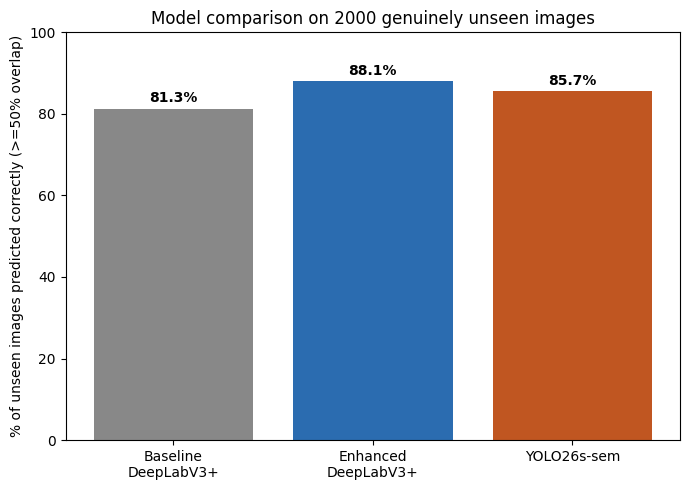

In [20]:
names = ["Baseline\nDeepLabV3+", "Enhanced\nDeepLabV3+", "YOLO26s-sem"]
accs = [baseline_acc, enhanced_acc, yolo_acc]
colors = ["#888888", "#2b6cb0", "#c05621"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(names, accs, color=colors)
ax.set_ylabel("% of unseen images predicted correctly (>=50% overlap)")
ax.set_title(f"Model comparison on {len(unseen_files)} genuinely unseen images")
ax.set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 1.5, f"{acc:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f'{CONFIG["out_dir"]}/accuracy_comparison.png', dpi=150)
plt.show()

## 9. Sample Predictions, Correct and Incorrect

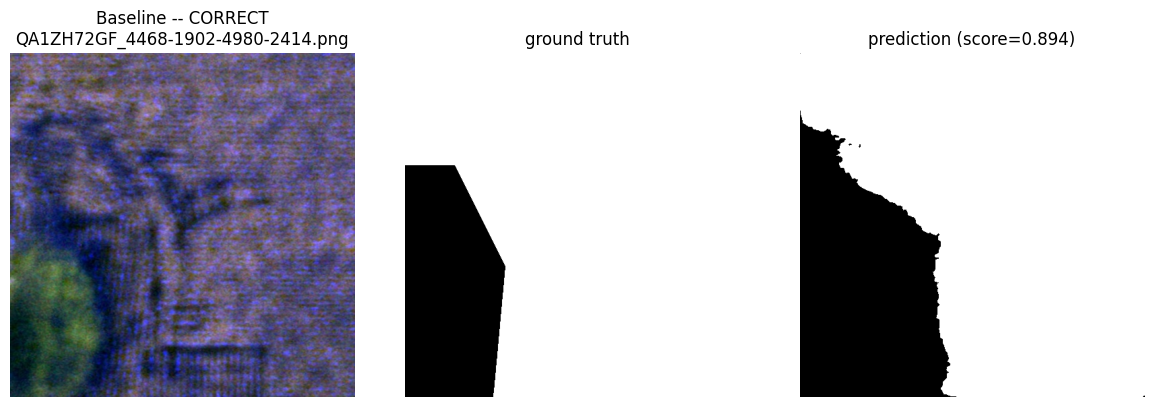

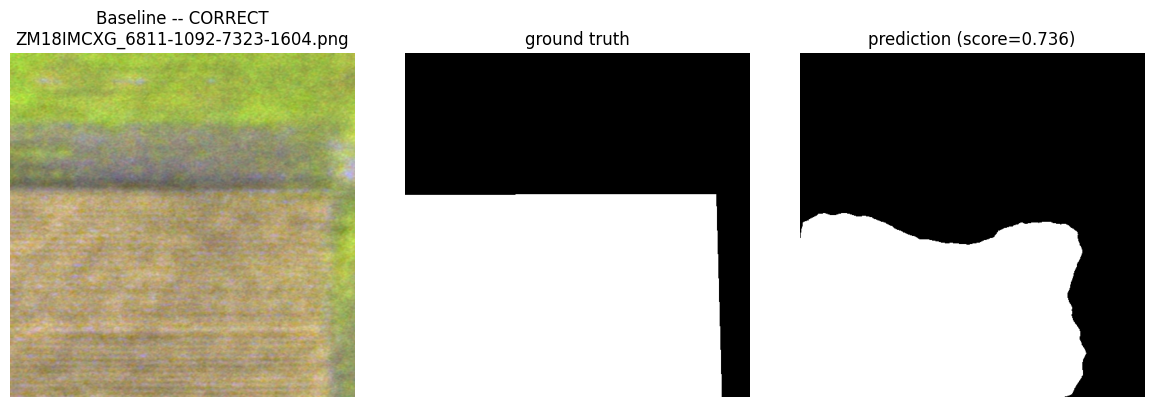

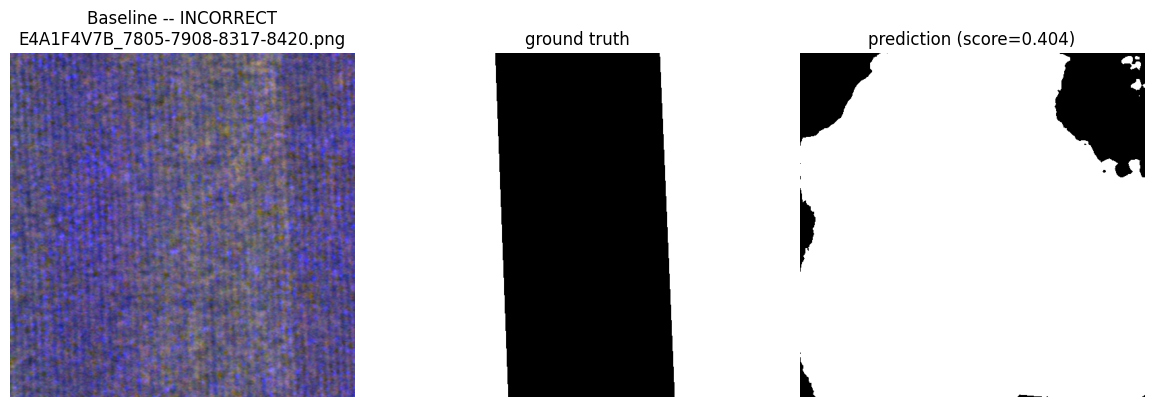

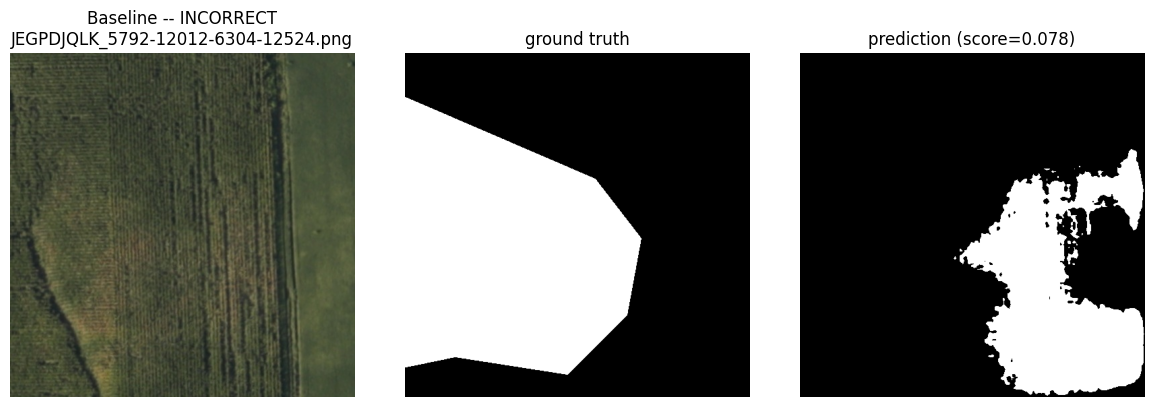

In [21]:
def show_samples(records, predict_fn, model_name, n=2):
    correct_ex = [r for r in records if r[3]][:n]
    incorrect_ex = [r for r in records if not r[3]][:n]
    for tag, examples in [("CORRECT", correct_ex), ("INCORRECT", incorrect_ex)]:
        for fname, is_pos, score, _ in examples:
            rgb_nir = load_rgb_nir(fname)
            target, valid = load_mask_and_valid(fname)
            pred = predict_fn(rgb_nir)

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(rgb_nir[:, :, :3])
            axes[0].set_title(f"{model_name} -- {tag}\n{fname}")
            axes[0].axis("off")
            axes[1].imshow(target, cmap="gray")
            axes[1].set_title("ground truth")
            axes[1].axis("off")
            axes[2].imshow(pred, cmap="gray")
            axes[2].set_title(f"prediction (score={score:.3f})")
            axes[2].axis("off")
            plt.tight_layout()
            plt.show()

show_samples(baseline_records, lambda rn: dlv3_predict(baseline_model, rn, CONFIG["baseline_thresh"]), "Baseline")

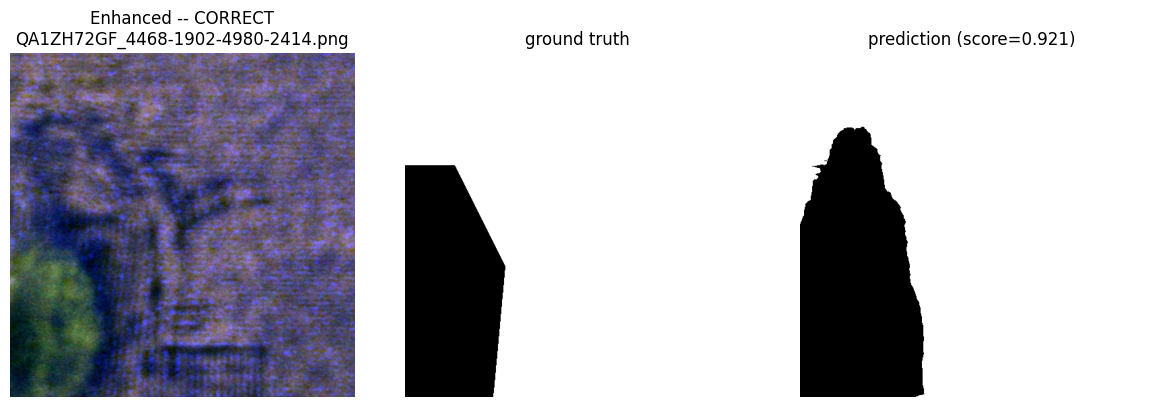

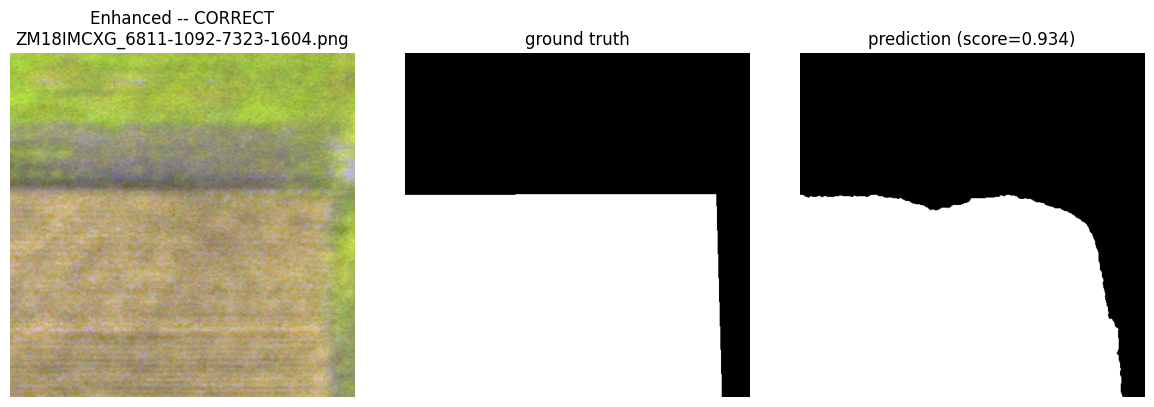

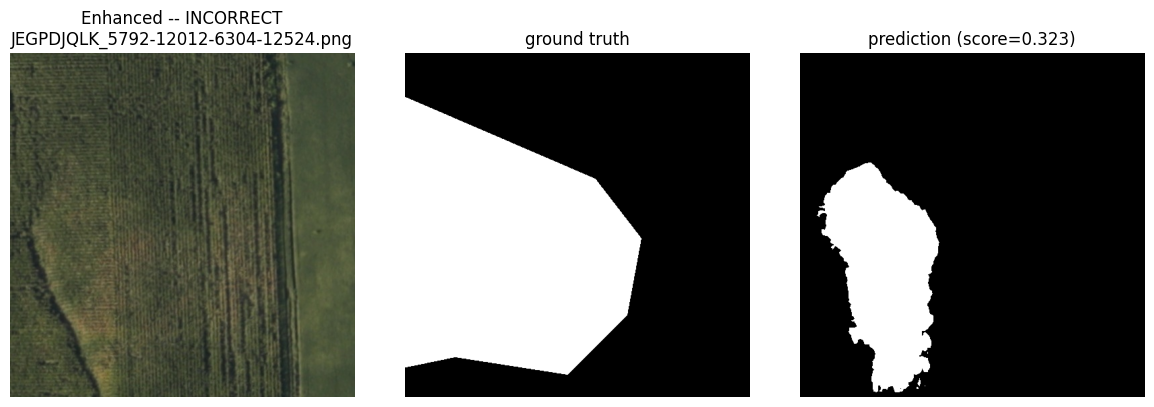

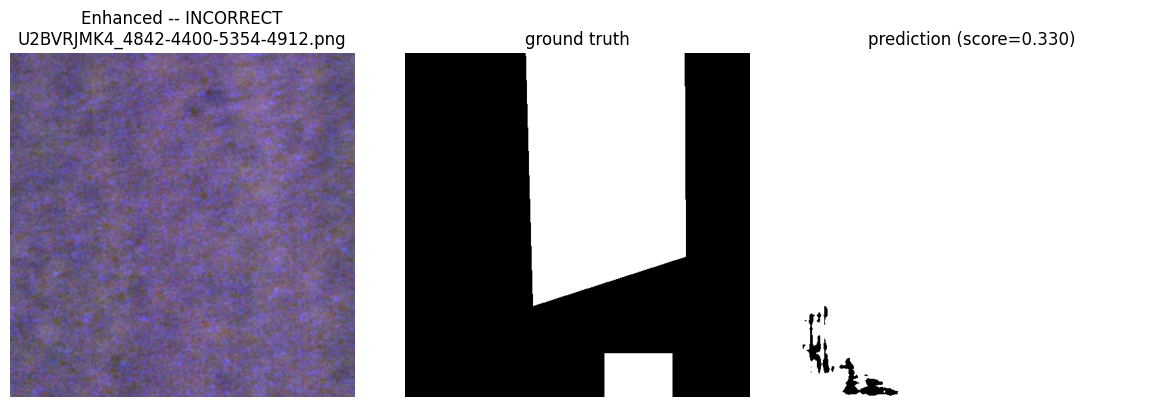

In [22]:
show_samples(enhanced_records, lambda rn: dlv3_predict(enhanced_model, rn, CONFIG["enhanced_thresh"]), "Enhanced")

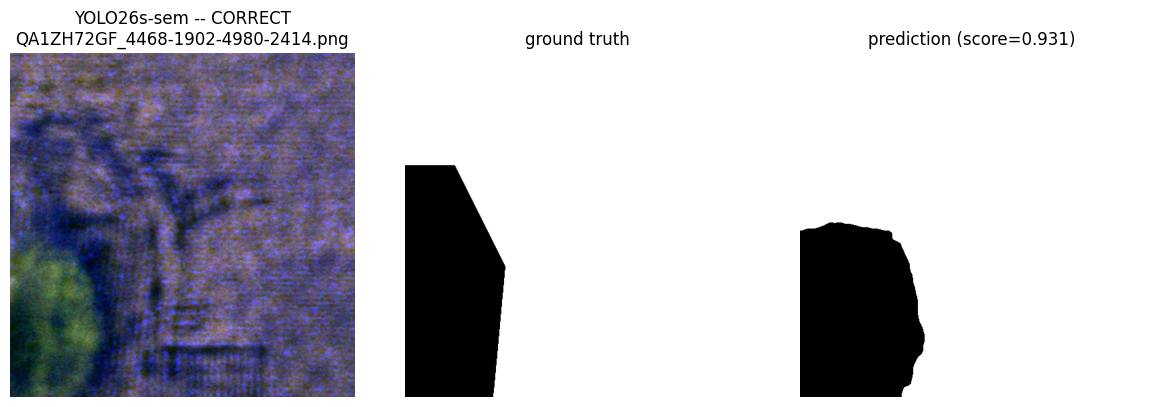

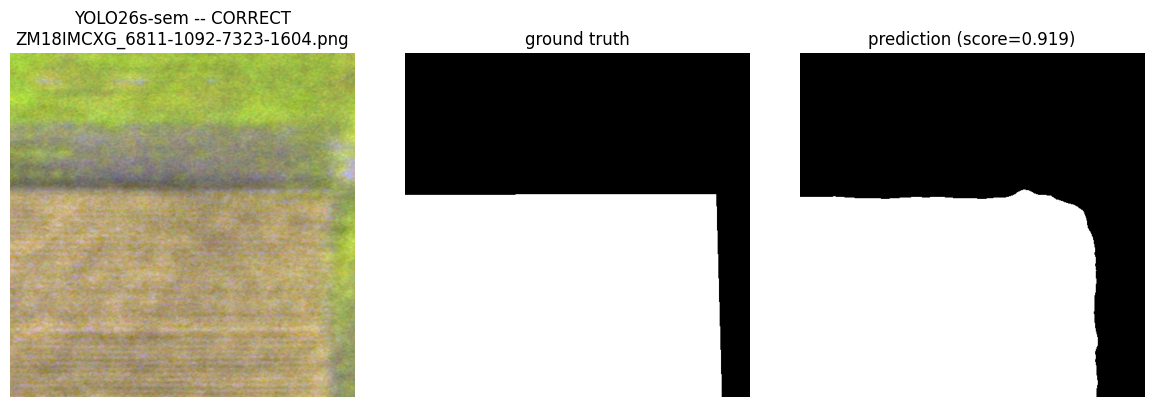

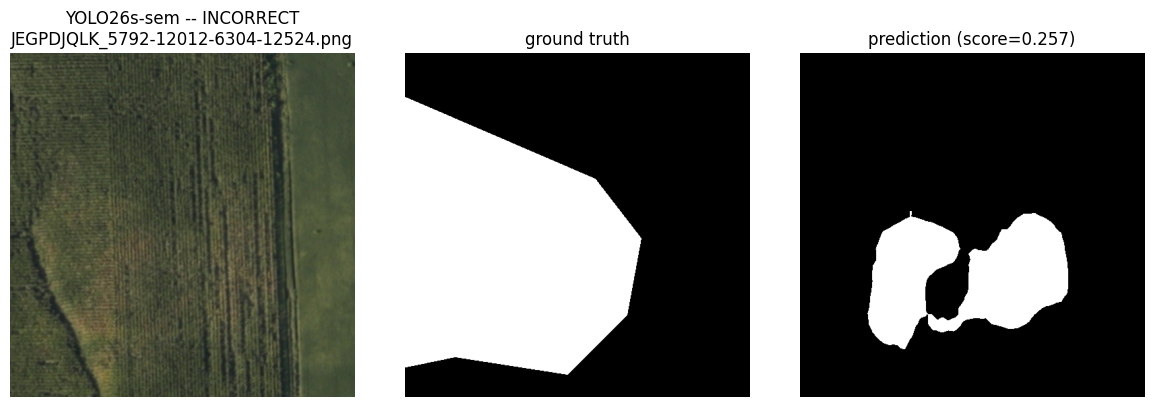

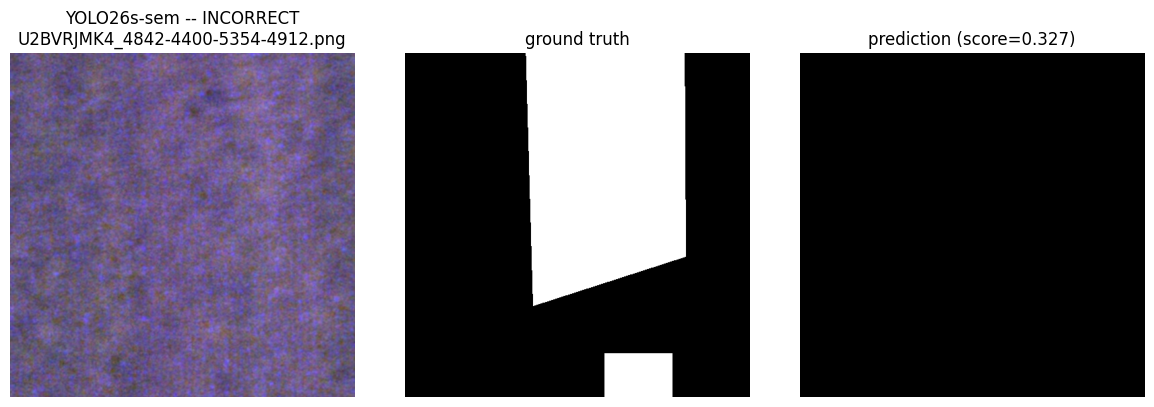

In [23]:
show_samples(yolo_records, yolo_predict, "YOLO26s-sem")

## 10. Training Curves, All Three Models

Baseline and Enhanced curves come from their real training logs. YOLO26 saves its own log
automatically, loaded directly from disk.

In [27]:
b_df = pd.read_csv(CONFIG["baseline_log_csv"])
b_epochs, b_train_loss, b_val_iou = b_df["epoch"], b_df["train_loss"], b_df["val_iou"]

e_df = pd.read_csv(CONFIG["enhanced_log_csv"])
e_epochs, e_train_loss, e_val_iou = e_df["epoch"], e_df["train_loss"], e_df["val_iou"]

yolo_df = pd.read_csv(CONFIG["yolo_results_csv"])

print("training logs loaded:", len(b_df), "baseline epochs,", len(e_df), "enhanced epochs,", len(yolo_df), "YOLO epochs")

training logs loaded: 100 baseline epochs, 65 enhanced epochs, 62 YOLO epochs


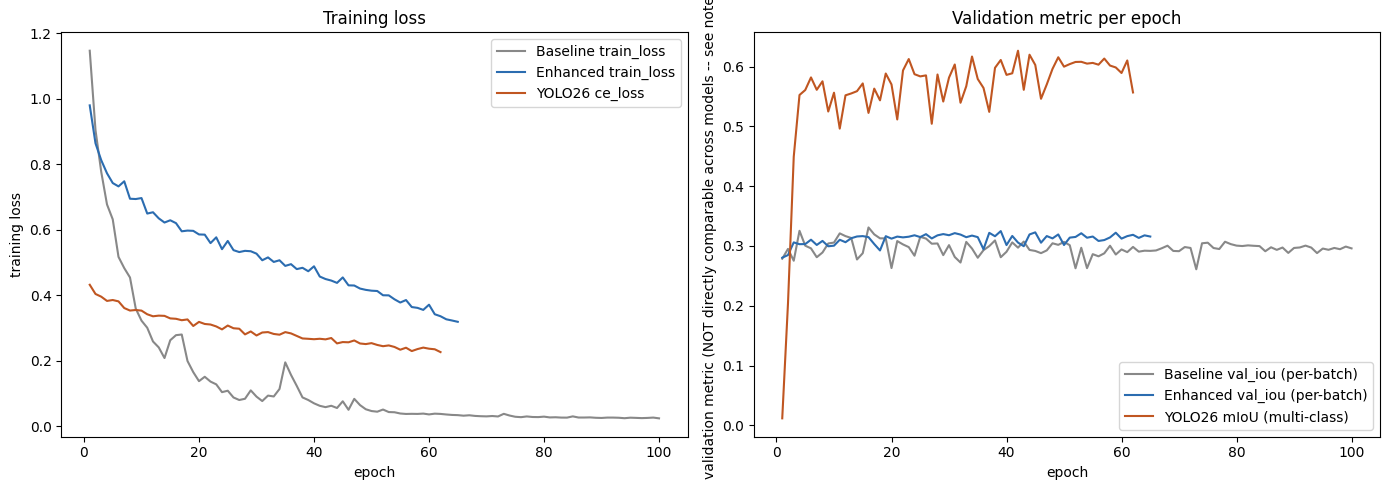

NOTE: baseline/enhanced val_iou is the understated per-batch DeepLabV3 metric (Methodology.md §8.1);
YOLO's mIoU averages in the easy background class. None of these three curves are on the same scale --
they show convergence SHAPE (still improving vs. plateaued), not an apples-to-apples height comparison.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(b_epochs, b_train_loss, label="Baseline train_loss", color="#888888")
axes[0].plot(e_epochs, e_train_loss, label="Enhanced train_loss", color="#2b6cb0")
if "train/ce_loss" in yolo_df.columns:
    axes[0].plot(yolo_df["epoch"], yolo_df["train/ce_loss"], label="YOLO26 ce_loss", color="#c05621")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss"); axes[0].legend(); axes[0].set_title("Training loss")

axes[1].plot(b_epochs, b_val_iou, label="Baseline val_iou (per-batch)", color="#888888")
axes[1].plot(e_epochs, e_val_iou, label="Enhanced val_iou (per-batch)", color="#2b6cb0")
miou_col = [c for c in yolo_df.columns if "miou" in c.lower()]
if miou_col:
    axes[1].plot(yolo_df["epoch"], yolo_df[miou_col[0]], label="YOLO26 mIoU (multi-class)", color="#c05621")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation metric (NOT directly comparable across models -- see note)")
axes[1].legend(); axes[1].set_title("Validation metric per epoch")

plt.tight_layout()
plt.savefig(f'{CONFIG["out_dir"]}/training_curves.png', dpi=150)
plt.show()
print("NOTE: baseline/enhanced val_iou is the understated per-batch DeepLabV3 metric (Methodology.md \u00a78.1);")
print("YOLO's mIoU averages in the easy background class. None of these three curves are on the same scale --")
print("they show convergence SHAPE (still improving vs. plateaued), not an apples-to-apples height comparison.")

## 11. Summary Table

In [29]:
summary = pd.DataFrame({
    "model": ["Baseline DeepLabV3+", "Enhanced DeepLabV3+", "YOLO26s-sem"],
    "unseen_pool_accuracy_pct": [baseline_acc, enhanced_acc, yolo_acc],
    "own_test_set_iou": [0.5342, 0.5790, 0.5700],
})
summary.to_csv(f'{CONFIG["out_dir"]}/summary.csv', index=False)
summary

,model,unseen_pool_accuracy_pct,own_test_set_iou
0,Baseline DeepLabV3+,81.30,0.5342
1,Enhanced DeepLabV3+,88.10,0.5790
2,YOLO26s-sem,85.65,0.5700


## 12. YOLO26's Own Diagnostic Plots

Ultralytics generates its own plots on every validation call. This pulls the most recent one in
automatically rather than a fixed run number, so it stays correct after any future rerun.

The confusion matrix shows balanced performance across both classes, background correct about 85
percent of the time, drydown about 86 percent, not skewed toward one class by default. The
validation grids, ground truth next to prediction, mostly match closely, with real misses
concentrated on complex boundary shapes, an ignored region the model fills in anyway, or an edge
that is close but not exact. Same story as the numbers, just visible directly.

In [30]:
import glob

yolo_runs_root = "/content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/runs/semantic"
val_dirs = sorted(
    glob.glob(f"{yolo_runs_root}/val-*"),
    key=lambda p: int(p.rsplit("-", 1)[-1]) if p.rsplit("-", 1)[-1].isdigit() else -1,
)
if not val_dirs:
    # first (unsuffixed) val run, if no later val-N run exists
    val_dirs = glob.glob(f"{yolo_runs_root}/val")

latest_val_dir = val_dirs[-1]
print(f"found {len(val_dirs)} val run(s), using the most recent: {latest_val_dir}")

found 4 val run(s), using the most recent: /content/drive/MyDrive/Rizoma/Ultralytics_YOLO26/runs/semantic/val-5


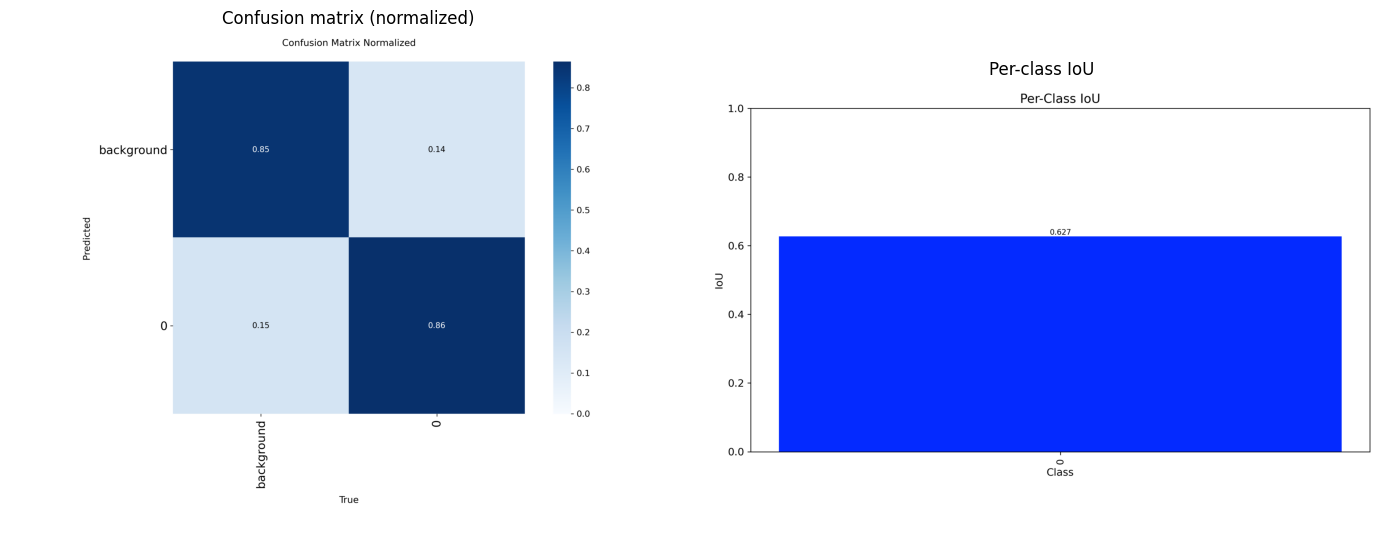

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(Image.open(f"{latest_val_dir}/confusion_matrix_normalized.png"))
axes[0].axis("off")
axes[0].set_title("Confusion matrix (normalized)")
axes[1].imshow(Image.open(f"{latest_val_dir}/iou_bar_chart.png"))
axes[1].axis("off")
axes[1].set_title("Per-class IoU")
plt.tight_layout()
plt.savefig(f'{CONFIG["out_dir"]}/yolo_diagnostic_summary.png', dpi=150)
plt.show()

In [32]:
import glob as _glob

batch_pairs = sorted(_glob.glob(f"{latest_val_dir}/val_batch*_labels.jpg"))
for labels_path in batch_pairs:
    pred_path = labels_path.replace("_labels.jpg", "_pred.jpg")
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(Image.open(labels_path))
    axes[0].axis("off")
    axes[0].set_title(f"Ground truth -- {labels_path.split('/')[-1]}")
    axes[1].imshow(Image.open(pred_path))
    axes[1].axis("off")
    axes[1].set_title(f"Prediction -- {pred_path.split('/')[-1]}")
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.